<center><h1>第三章 购物篮分析</h1></center>

本节算法实践 采用arules包的Apriori算法来进行购物篮分析，数据集来自现实中的超市一个月经营的购物数据，数据包含9835次交易，大约每天327次交易。

In [1]:
#首先安装关联规则包
install.packages('arules')

Installing package into ‘/home/shf/R/x86_64-pc-linux-gnu-library/3.4’
(as ‘lib’ is unspecified)


In [2]:
#导入关联规则包
library('arules')

Loading required package: Matrix

Attaching package: ‘arules’

The following objects are masked from ‘package:base’:

    abbreviate, write



In [3]:
#读取零售商的数据
groceries <- read.transactions("/home/shf/Data/groceries.csv", sep = ",")

In [4]:
groceries
#查看数据信息

transactions in sparse format with
 9835 transactions (rows) and
 169 items (columns)

In [5]:
summary(groceries)
#数据的基本汇总信息

transactions as itemMatrix in sparse format with
 9835 rows (elements/itemsets/transactions) and
 169 columns (items) and a density of 0.02609146 

most frequent items:
      whole milk other vegetables       rolls/buns             soda 
            2513             1903             1809             1715 
          yogurt          (Other) 
            1372            34055 

element (itemset/transaction) length distribution:
sizes
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
2159 1643 1299 1005  855  645  545  438  350  246  182  117   78   77   55   46 
  17   18   19   20   21   22   23   24   26   27   28   29   32 
  29   14   14    9   11    4    6    1    1    1    1    3    1 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   3.000   4.409   6.000  32.000 

includes extended item information - examples:
            labels
1 abrasive cleaner
2 artif. sweetener
3   baby cosmetics

In [6]:
# 查看前5个交易数据
inspect(groceries[1:5])

    items                     
[1] {citrus fruit,            
     margarine,               
     ready soups,             
     semi-finished bread}     
[2] {coffee,                  
     tropical fruit,          
     yogurt}                  
[3] {whole milk}              
[4] {cream cheese,            
     meat spreads,            
     pip fruit,               
     yogurt}                  
[5] {condensed milk,          
     long life bakery product,
     other vegetables,        
     whole milk}              


In [7]:
#查看前3个项目的频率
itemFrequency(groceries[, 1:3])

abrasive cleaner artif. sweetener   baby cosmetics 
    0.0035587189     0.0032536858     0.0006100661

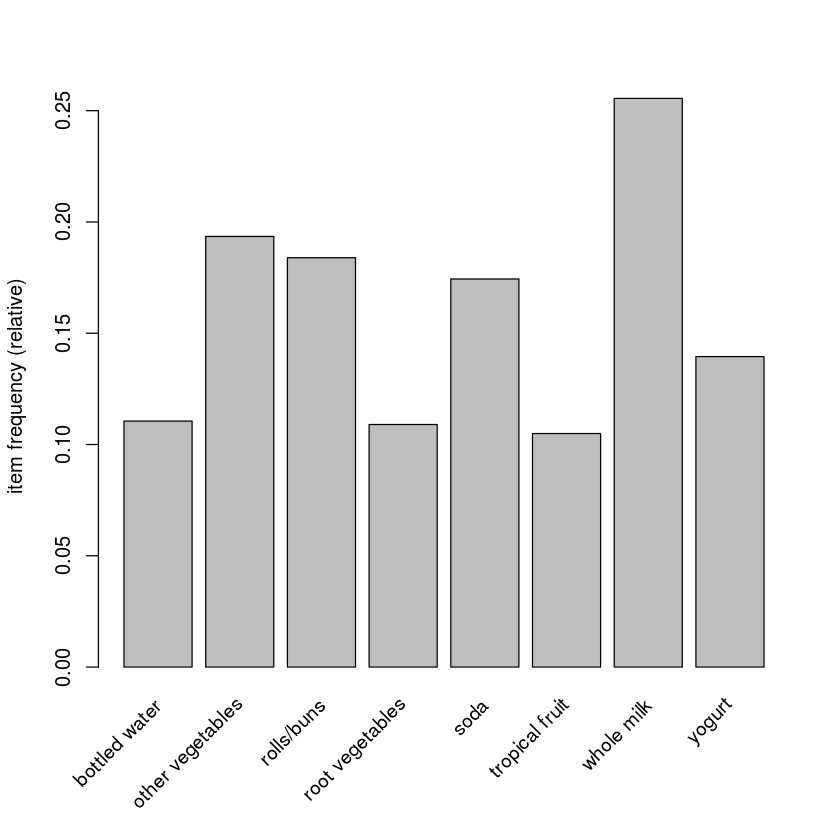

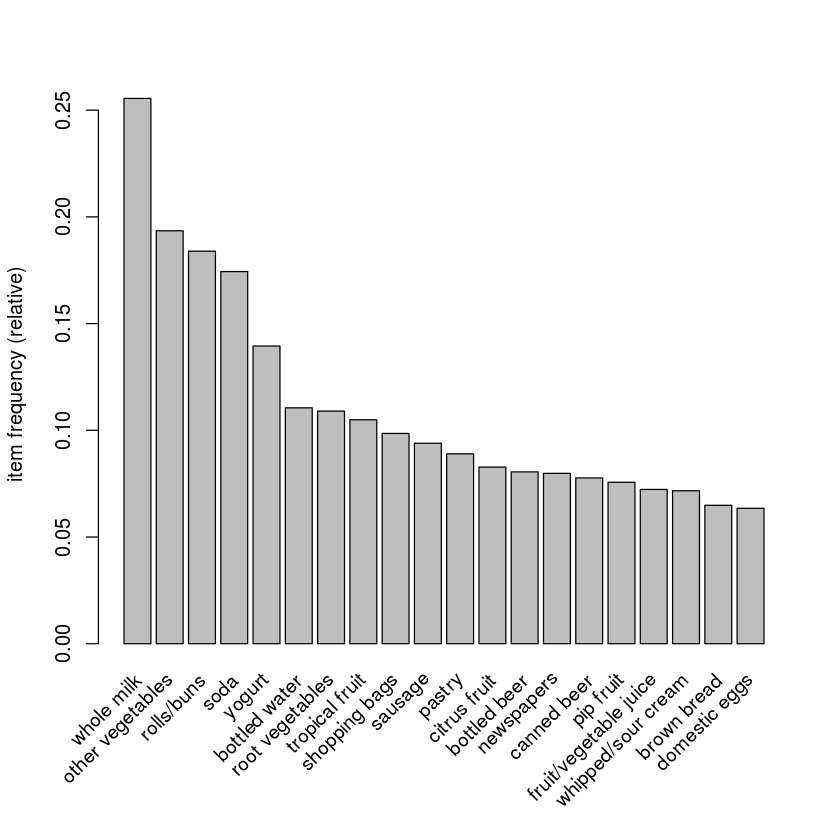

In [8]:
#画出项目的频率，支持度设定为0.1
itemFrequencyPlot(groceries, support = 0.1)
itemFrequencyPlot(groceries, topN = 20)

In [9]:
#对前5个交易数据画图
#image(groceries[1:5])

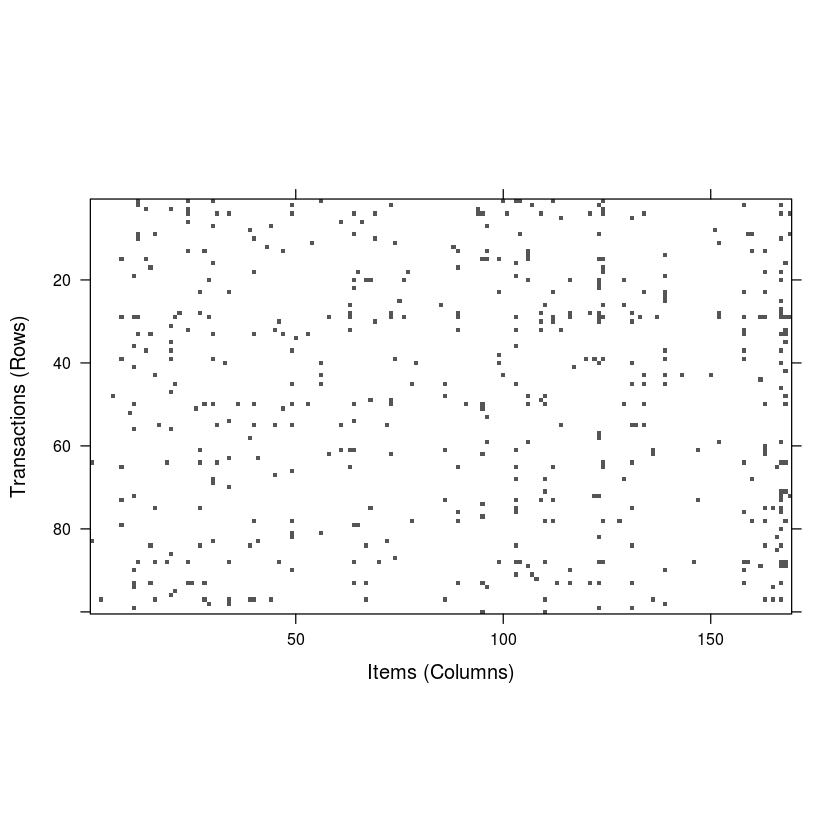

In [10]:
#随机取100个交易数据，作图
image(sample(groceries, 100))

In [11]:
#采用apriori算法处理数据，参数采用默认的设置
apriori(groceries)

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5     0.1      1
 maxlen target   ext
     10  rules FALSE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 983 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.00s].
sorting and recoding items ... [8 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 done [0.00s].
writing ... [0 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


set of 0 rules 

In [12]:
#自己根据数据设定参数，包括支持度，置信度，频繁项集最小长度
groceryrules <- apriori(groceries, parameter = list(support =
                          0.006, confidence = 0.25, minlen = 2))

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
       0.25    0.1    1 none FALSE            TRUE       5   0.006      2
 maxlen target   ext
     10  rules FALSE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 59 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.00s].
sorting and recoding items ... [109 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 done [0.00s].
writing ... [463 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


In [13]:
#根据apriori算法得到的关联规则
groceryrules

set of 463 rules 

In [14]:
#查看算法的基本结果
summary(groceryrules)

set of 463 rules

rule length distribution (lhs + rhs):sizes
  2   3   4 
150 297  16 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   2.000   3.000   2.711   3.000   4.000 

summary of quality measures:
    support           confidence          lift            count      
 Min.   :0.006101   Min.   :0.2500   Min.   :0.9932   Min.   : 60.0  
 1st Qu.:0.007117   1st Qu.:0.2971   1st Qu.:1.6229   1st Qu.: 70.0  
 Median :0.008744   Median :0.3554   Median :1.9332   Median : 86.0  
 Mean   :0.011539   Mean   :0.3786   Mean   :2.0351   Mean   :113.5  
 3rd Qu.:0.012303   3rd Qu.:0.4495   3rd Qu.:2.3565   3rd Qu.:121.0  
 Max.   :0.074835   Max.   :0.6600   Max.   :3.9565   Max.   :736.0  

mining info:
      data ntransactions support confidence
 groceries          9835   0.006       0.25

In [15]:
#查看前3个关联规则
inspect(groceryrules[1:3])

    lhs                rhs               support     confidence lift     count
[1] {potted plants} => {whole milk}      0.006914082 0.4000000  1.565460 68   
[2] {pasta}         => {whole milk}      0.006100661 0.4054054  1.586614 60   
[3] {herbs}         => {root vegetables} 0.007015760 0.4312500  3.956477 69   


 第一个规则说明：购买盆栽植物(potted plants)的顾客，有40%的概率也会买全脂奶(whole milk)。
 
第二个规则说明：购买意大利面（pasta)的顾客，有0.405的概率也会买全脂奶(whole milk)。

第三个规则说明：购买香草（herbs)的顾客，有0.431的概率也会买根类蔬菜(root vegetables)。

In [16]:
# 根据提升度对关联规则进行排序
inspect(sort(groceryrules, by = "lift")[1:5])

    lhs                   rhs                      support confidence     lift count
[1] {herbs}            => {root vegetables}    0.007015760  0.4312500 3.956477    69
[2] {berries}          => {whipped/sour cream} 0.009049314  0.2721713 3.796886    89
[3] {other vegetables,                                                              
     tropical fruit,                                                                
     whole milk}       => {root vegetables}    0.007015760  0.4107143 3.768074    69
[4] {beef,                                                                          
     other vegetables} => {root vegetables}    0.007930859  0.4020619 3.688692    78
[5] {other vegetables,                                                              
     tropical fruit}   => {pip fruit}          0.009456024  0.2634561 3.482649    93


In [17]:
#找出关于 berry这个项目的规则
berryrules <- subset(groceryrules, items %in% "berries")
inspect(berryrules)

    lhs          rhs                  support     confidence lift     count
[1] {berries} => {whipped/sour cream} 0.009049314 0.2721713  3.796886  89  
[2] {berries} => {yogurt}             0.010574479 0.3180428  2.279848 104  
[3] {berries} => {other vegetables}   0.010269446 0.3088685  1.596280 101  
[4] {berries} => {whole milk}         0.011794611 0.3547401  1.388328 116  


In [18]:
#保存规则到文件
write(groceryrules, file = "groceryrules.csv",
      sep = ",", quote = TRUE, row.names = FALSE)

In [19]:
# 将关联规则转成data.frame
groceryrules_df <- as(groceryrules, "data.frame")
str(groceryrules_df)

'data.frame':	463 obs. of  5 variables:
 $ rules     : Factor w/ 463 levels "{baking powder} => {other vegetables}",..: 340 302 207 206 208 341 402 21 139 140 ...
 $ support   : num  0.00691 0.0061 0.00702 0.00773 0.00773 ...
 $ confidence: num  0.4 0.405 0.431 0.475 0.475 ...
 $ lift      : num  1.57 1.59 3.96 2.45 1.86 ...
 $ count     : num  68 60 69 76 76 69 70 67 63 88 ...
